# Image Classification

  - Cats and Dogs dataset


## Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.15.0


## Data preprocessing
### Data download
In this tutorial, you will use a dataset containing several thousand images of cats and dogs. Download and extract a zip file containing the images, then create a `tf.data.Dataset` for training and validation using the `tf.keras.utils.image_dataset_from_directory` utility.

In [ ]:
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=_URL, extract=True)
PATH = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

BATCH_SIZE = 32
img_height = 160
img_width = 160
IMG_SIZE = (img_height, img_width)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

Found 2000 files belonging to 2 classes.


In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)

Found 1000 files belonging to 2 classes.


### Show some images

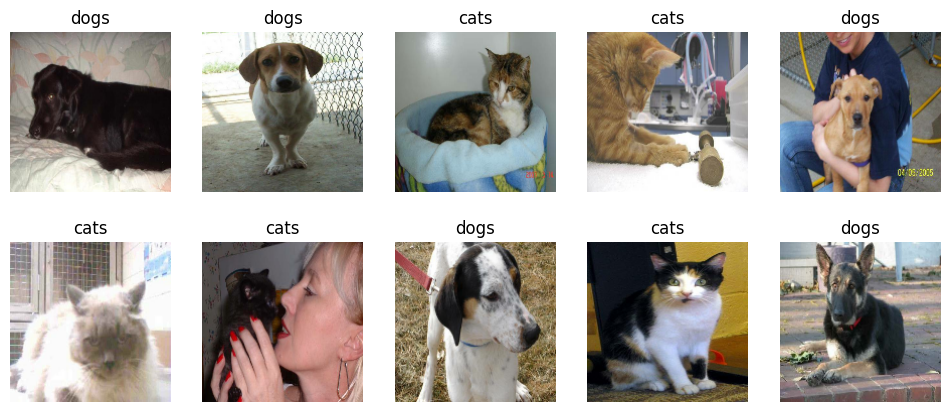

In [ ]:
class_names = train_dataset.class_names

plt.figure(figsize=(12, 5))
for images, labels in train_dataset.take(1):
  for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

### Split the data
As the original dataset doesn't contain a test set, you will create one. To do so, determine how many batches of data are available in the validation set using tf.data.experimental.cardinality, then move 20% of them to a test set.

In [ ]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 26
Number of test batches: 6


### Configure the dataset for performance
Use buffered prefetching to load images from disk without having I/O become blocking.

To learn more about this method see the [data performance](https://www.tensorflow.org/guide/data_performance) guide.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## A basic Keras model
### VGG-1 model


In [ ]:
from keras.api._v2.keras import metrics
from keras.models import Sequential
from keras.optimizers import SGD
from keras import layers

# define a model with 1 VGG block
model = Sequential([
  layers.Rescaling (1./255, input_shape=(160, 160, 3)),
  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
  layers.Dense(1, activation='sigmoid')
])

# compile the model
opt = SGD(learning_rate=0.001, momentum=0.9)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 160, 160, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 160, 160, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 80, 80, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 204800)            0         
                                                                 
 dense (Dense)               (None, 128)               26214528  
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                        

In [ ]:
# train the model
epochs=20
history = model.fit(
  train_dataset,
  validation_data=validation_dataset,
  epochs=epochs
)

Epoch 1/20
63/63 [==============================] - 11s 70ms/step - loss: 0.7226 - accuracy: 0.5175 - val_loss: 0.6821 - val_accuracy: 0.5644
Epoch 2/20
63/63 [==============================] - 4s 52ms/step - loss: 0.6933 - accuracy: 0.5395 - val_loss: 0.6890 - val_accuracy: 0.5656
Epoch 3/20
63/63 [==============================] - 5s 65ms/step - loss: 0.6865 - accuracy: 0.5515 - val_loss: 0.6820 - val_accuracy: 0.5594
Epoch 4/20
63/63 [==============================] - 3s 46ms/step - loss: 0.6824 - accuracy: 0.5525 - val_loss: 0.6748 - val_accuracy: 0.5693
Epoch 5/20
63/63 [==============================] - 3s 52ms/step - loss: 0.6705 - accuracy: 0.5750 - val_loss: 0.6860 - val_accuracy: 0.5396
Epoch 6/20
63/63 [==============================] - 5s 66ms/step - loss: 0.6552 - accuracy: 0.6265 - val_loss: 0.6651 - val_accuracy: 0.5619
Epoch 7/20
63/63 [==============================] - 3s 46ms/step - loss: 0.6527 - accuracy: 0.6060 - val_loss: 0.6732 - val_accuracy: 0.6064
Epoch 8/20
6

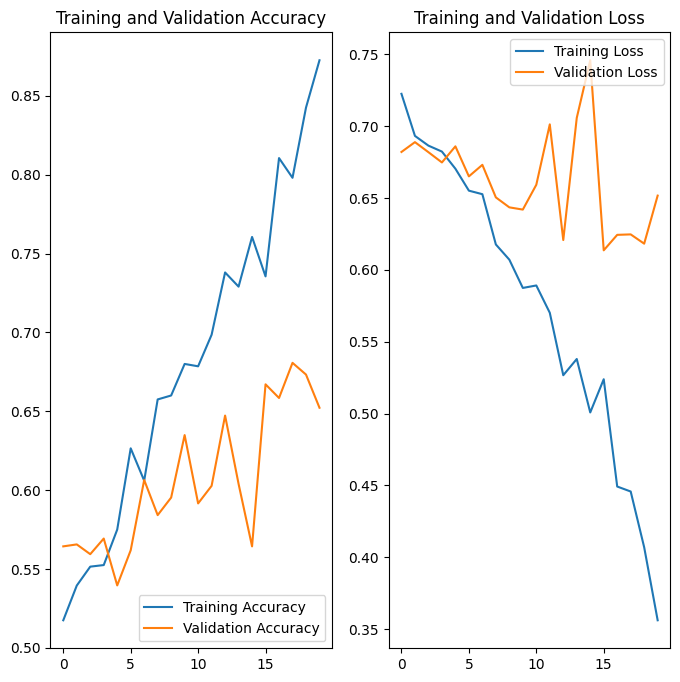

In [ ]:
# visualize training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### VGG-2 model

In [ ]:
from keras.api._v2.keras import metrics
from keras.models import Sequential
from keras.optimizers import SGD
from keras import layers

# define a model with 2 VGG blocks
model = Sequential([
  layers.Rescaling (1./255, input_shape=(160, 160, 3)),

  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),

  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),

  layers.Flatten(),
  layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
  layers.Dense(1, activation='sigmoid')
])

# compile the model
opt = SGD(learning_rate=0.001, momentum=0.9)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# train the model
epochs=20
history = model.fit(
  train_dataset,
  validation_data=validation_dataset,
  epochs=epochs
)

Epoch 1/20
63/63 [==============================] - 6s 70ms/step - loss: 0.8180 - accuracy: 0.5050 - val_loss: 0.6928 - val_accuracy: 0.5012
Epoch 2/20
63/63 [==============================] - 3s 45ms/step - loss: 0.6927 - accuracy: 0.5135 - val_loss: 0.6896 - val_accuracy: 0.5396
Epoch 3/20
63/63 [==============================] - 3s 46ms/step - loss: 0.6891 - accuracy: 0.5215 - val_loss: 0.6830 - val_accuracy: 0.5619
Epoch 4/20
63/63 [==============================] - 3s 50ms/step - loss: 0.6894 - accuracy: 0.5285 - val_loss: 0.6852 - val_accuracy: 0.5619
Epoch 5/20
63/63 [==============================] - 4s 65ms/step - loss: 0.6863 - accuracy: 0.5570 - val_loss: 0.6768 - val_accuracy: 0.5743
Epoch 6/20
63/63 [==============================] - 3s 47ms/step - loss: 0.6753 - accuracy: 0.5875 - val_loss: 0.6731 - val_accuracy: 0.5804
Epoch 7/20
63/63 [==============================] - 6s 84ms/step - loss: 0.6744 - accuracy: 0.5660 - val_loss: 0.6663 - val_accuracy: 0.5866
Epoch 8/20
63

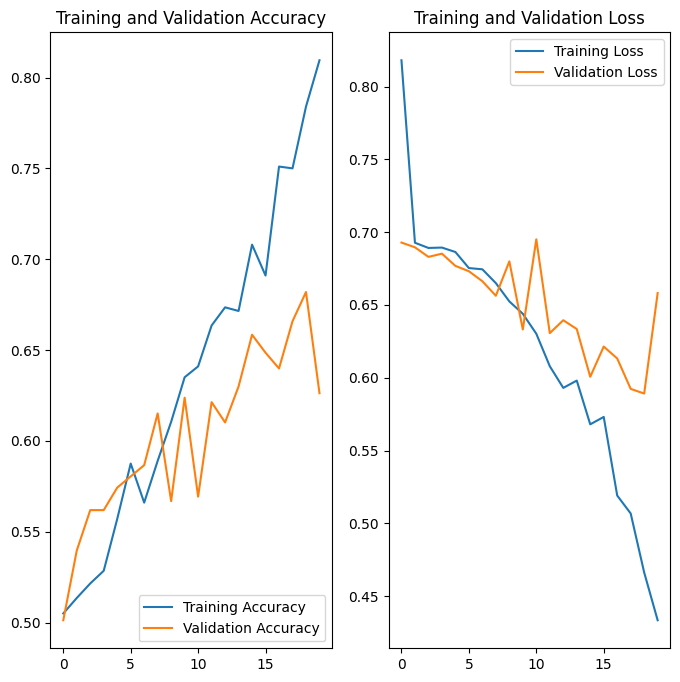

In [ ]:
# visualize training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### VGG-3 model

In [ ]:
from keras.api._v2.keras import metrics
from keras.models import Sequential
from keras.optimizers import SGD
from keras import layers

# define a model with 3 VGG block3
model = Sequential([
  layers.Rescaling (1./255, input_shape=(160, 160, 3)),

  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),

  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),

  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),

  layers.Flatten(),
  layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
  layers.Dense(1, activation='sigmoid')
])

# compile the model
opt = SGD(learning_rate=0.001, momentum=0.9)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# train the model
epochs=20
history = model.fit(
  train_dataset,
  validation_data=validation_dataset,
  epochs=epochs
)

Epoch 1/20
63/63 [==============================] - 6s 61ms/step - loss: 0.6871 - accuracy: 0.5365 - val_loss: 0.6559 - val_accuracy: 0.6015
Epoch 2/20
63/63 [==============================] - 4s 53ms/step - loss: 0.6569 - accuracy: 0.6130 - val_loss: 0.6417 - val_accuracy: 0.6448
Epoch 3/20
63/63 [==============================] - 4s 61ms/step - loss: 0.6430 - accuracy: 0.6320 - val_loss: 0.6230 - val_accuracy: 0.6770
Epoch 4/20
63/63 [==============================] - 3s 47ms/step - loss: 0.6200 - accuracy: 0.6650 - val_loss: 0.6176 - val_accuracy: 0.6733
Epoch 5/20
63/63 [==============================] - 3s 47ms/step - loss: 0.6091 - accuracy: 0.6725 - val_loss: 0.6269 - val_accuracy: 0.6225
Epoch 6/20
63/63 [==============================] - 4s 61ms/step - loss: 0.5780 - accuracy: 0.6935 - val_loss: 0.6085 - val_accuracy: 0.6856
Epoch 7/20
63/63 [==============================] - 4s 50ms/step - loss: 0.5474 - accuracy: 0.7255 - val_loss: 0.6256 - val_accuracy: 0.6200
Epoch 8/20
63

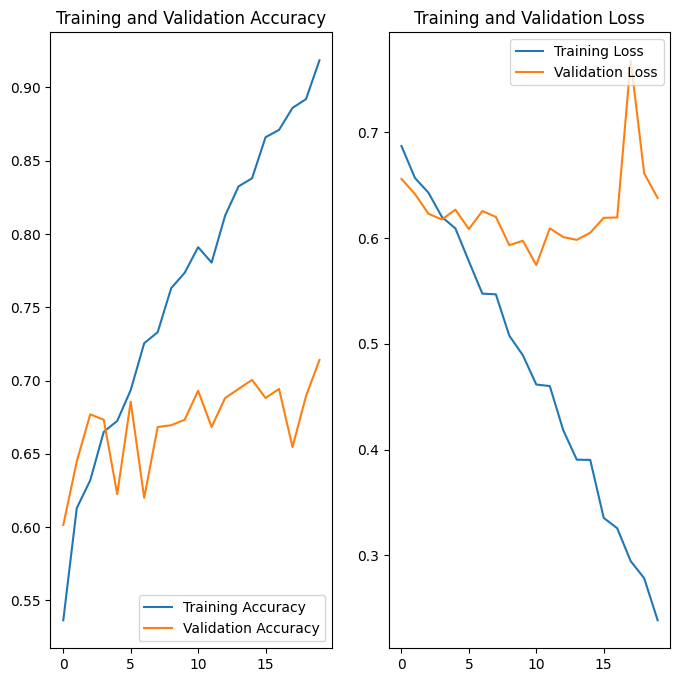

In [ ]:
# visualize training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Model improvements
- Data augmentation
- Dropouts

In [ ]:
# data augmentation
data_augmentation = Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

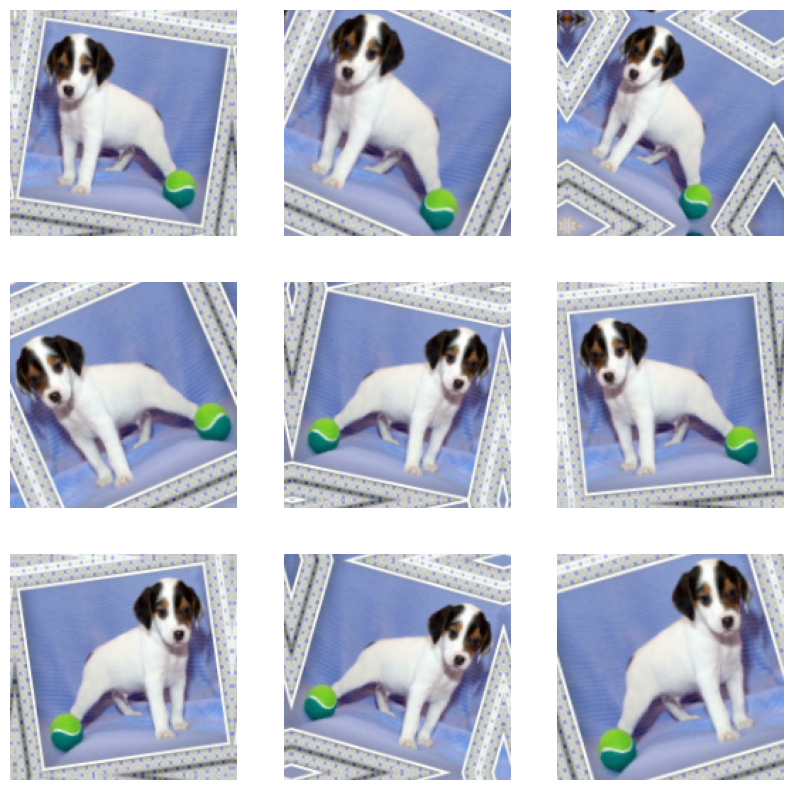

In [ ]:
# show some images
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
# define a model with 1 VGG block
model = Sequential([
  data_augmentation,
  layers.Rescaling (1./255),
  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.2),

  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.2),

  layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.2),

  layers.Flatten(),
  layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
  layers.Dense(1, activation='sigmoid')
])

# compile the model
opt = SGD(learning_rate=0.001, momentum=0.9)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# model summary
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (None, 160, 160, 3)       0         
                                                                 
 rescaling_3 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 160, 160, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 80, 80, 32)        0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 80, 80, 32)        0         
                                                                 
 conv2d_7 (Conv2D)           (None, 80, 80, 32)        9248      
                                                      

In [ ]:
# train the model
epochs=50
history = model.fit(
  train_dataset,
  validation_data=validation_dataset,
  epochs=epochs
)

Epoch 1/50
63/63 [==============================] - 7s 73ms/step - loss: 0.7415 - accuracy: 0.5070 - val_loss: 0.6866 - val_accuracy: 0.5470
Epoch 2/50
63/63 [==============================] - 4s 53ms/step - loss: 0.6968 - accuracy: 0.5460 - val_loss: 0.6881 - val_accuracy: 0.5433
Epoch 3/50
63/63 [==============================] - 4s 54ms/step - loss: 0.6897 - accuracy: 0.5385 - val_loss: 0.6861 - val_accuracy: 0.5681
Epoch 4/50
63/63 [==============================] - 4s 64ms/step - loss: 0.6785 - accuracy: 0.5620 - val_loss: 0.6831 - val_accuracy: 0.5854
Epoch 5/50
63/63 [==============================] - 4s 62ms/step - loss: 0.6855 - accuracy: 0.5450 - val_loss: 0.6862 - val_accuracy: 0.5458
Epoch 6/50
63/63 [==============================] - 4s 60ms/step - loss: 0.6750 - accuracy: 0.5645 - val_loss: 0.6807 - val_accuracy: 0.5767
Epoch 7/50
63/63 [==============================] - 4s 56ms/step - loss: 0.6726 - accuracy: 0.5820 - val_loss: 0.6804 - val_accuracy: 0.5755
Epoch 8/50
63

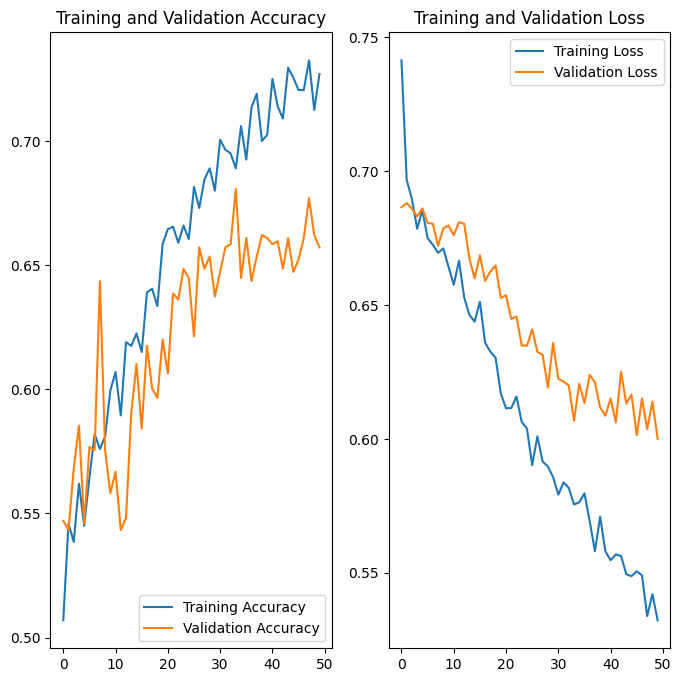

In [ ]:
# visualize training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Overfitting still an issue potentially because the training data dataset is too small to model variablity in the dataset. Let's try transfer learning to take advantage of one of the pretrained models.

## Transfer Learning with MobileNet V2
You will create the base model from the MobileNet V2 model developed at Google. This is pre-trained on the ImageNet dataset, a large dataset consisting of 1.4M images and 1000 classes. ImageNet is a research training dataset with a wide variety of categories like jackfruit and syringe. This base of knowledge will help us classify cats and dogs from our specific dataset.

First, you need to pick which layer of MobileNet V2 you will use for feature extraction. The very last classification layer (on "top", as most diagrams of machine learning models go from bottom to top) is not very useful. Instead, you will follow the common practice to depend on the very last layer before the flatten operation. This layer is called the "bottleneck layer". The bottleneck layer features retain more generality as compared to the final/top layer.

First, instantiate a MobileNet V2 model pre-loaded with weights trained on ImageNet. By specifying the include_top=False argument, you load a network that doesn't include the classification layers at the top, which is ideal for feature extraction.